# 工业蒸汽预测

### 一、预备知识

In [78]:
# 卡方检验
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
iris = load_iris()                                        # .fit(x, y): 拟合数据，计算每个特征的卡方得分
x, y = iris.data, iris.target                           # .transform(x): 转换数据，保留得分最高的2个特征
chiValues = chi2(x,y)                                   # .fit_transform(x, y): 将上述两个步骤合并执行
x_new = SelectKBest(chi2, k= 2).fit_transform(x, y) # SelectKBest(评分函数, k) k：指定要选择的最佳特征数量

In [79]:
chiValues # 第一行：卡方统计量、第二行：p值

(array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ]),
 array([4.47651499e-03, 1.56395980e-01, 5.53397228e-26, 2.75824965e-15]))

In [80]:
# 观察类别型和连续型双变量---小提琴图
# 异常值---箱线图、散点图；处理：删除、转换（取对数）、填充、区别对待
# 变量转换---缩放/标准化、非线性变线性、对数变换/取平方 立方 指数、变量分组
# 新变量生成---基于旧变量函数组合创建新变量，独热编码

### 二、数据描述

In [81]:
# 导入工具库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [105]:
train_data = pd.read_csv("./zhengqi_train.txt", sep = '\t', encoding = 'utf-8')
test_data = pd.read_csv("./zhengqi_test.txt", sep = '\t', encoding = 'utf-8')

In [83]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 39 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V0      2888 non-null   float64
 1   V1      2888 non-null   float64
 2   V2      2888 non-null   float64
 3   V3      2888 non-null   float64
 4   V4      2888 non-null   float64
 5   V5      2888 non-null   float64
 6   V6      2888 non-null   float64
 7   V7      2888 non-null   float64
 8   V8      2888 non-null   float64
 9   V9      2888 non-null   float64
 10  V10     2888 non-null   float64
 11  V11     2888 non-null   float64
 12  V12     2888 non-null   float64
 13  V13     2888 non-null   float64
 14  V14     2888 non-null   float64
 15  V15     2888 non-null   float64
 16  V16     2888 non-null   float64
 17  V17     2888 non-null   float64
 18  V18     2888 non-null   float64
 19  V19     2888 non-null   float64
 20  V20     2888 non-null   float64
 21  V21     2888 non-null   float64
 22  

In [84]:
train_data.describe()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V29,V30,V31,V32,V33,V34,V35,V36,V37,target
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,...,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000
mean,0.123048,0.056068,0.289720,-0.067790,0.012921,-0.558565,0.182892,0.116155,0.177856,-0.169452,...,0.097648,0.055477,0.127791,0.020806,0.007801,0.006715,0.197764,0.030658,-0.130330,0.126353
std,0.928031,0.941515,0.911236,0.970298,0.888377,0.517957,0.918054,0.955116,0.895444,0.953813,...,1.061200,0.901934,0.873028,0.902584,1.006995,1.003291,0.985675,0.970812,1.017196,0.983966
min,-4.335000,-5.122000,-3.420000,-3.956000,-4.742000,-2.182000,-4.576000,-5.048000,-4.692000,-12.891000,...,-2.912000,-4.507000,-5.859000,-4.053000,-4.627000,-4.789000,-5.695000,-2.608000,-3.630000,-3.044000
25%,-0.297000,-0.226250,-0.313000,-0.652250,-0.385000,-0.853000,-0.310000,-0.295000,-0.159000,-0.390000,...,-0.664000,-0.283000,-0.170250,-0.407250,-0.499000,-0.290000,-0.202500,-0.413000,-0.798250,-0.350250
50%,0.359000,0.272500,0.386000,-0.044500,0.110000,-0.466000,0.388000,0.344000,0.362000,0.042000,...,-0.023000,0.053500,0.299500,0.039000,-0.040000,0.160000,0.364000,0.137000,-0.185500,0.313000
75%,0.726000,0.599000,0.918250,0.624000,0.550250,-0.154000,0.831250,0.782250,0.726000,0.042000,...,0.745250,0.488000,0.635000,0.557000,0.462000,0.273000,0.602000,0.644250,0.495250,0.793250
max,2.121000,1.918000,2.828000,2.457000,2.689000,0.489000,1.895000,1.918000,2.245000,1.335000,...,4.580000,2.689000,2.013000,2.395000,5.465000,5.110000,2.324000,5.238000,3.000000,2.538000


#### 可视化数据分布

In [85]:
column = train_data.columns.tolist()[:38]

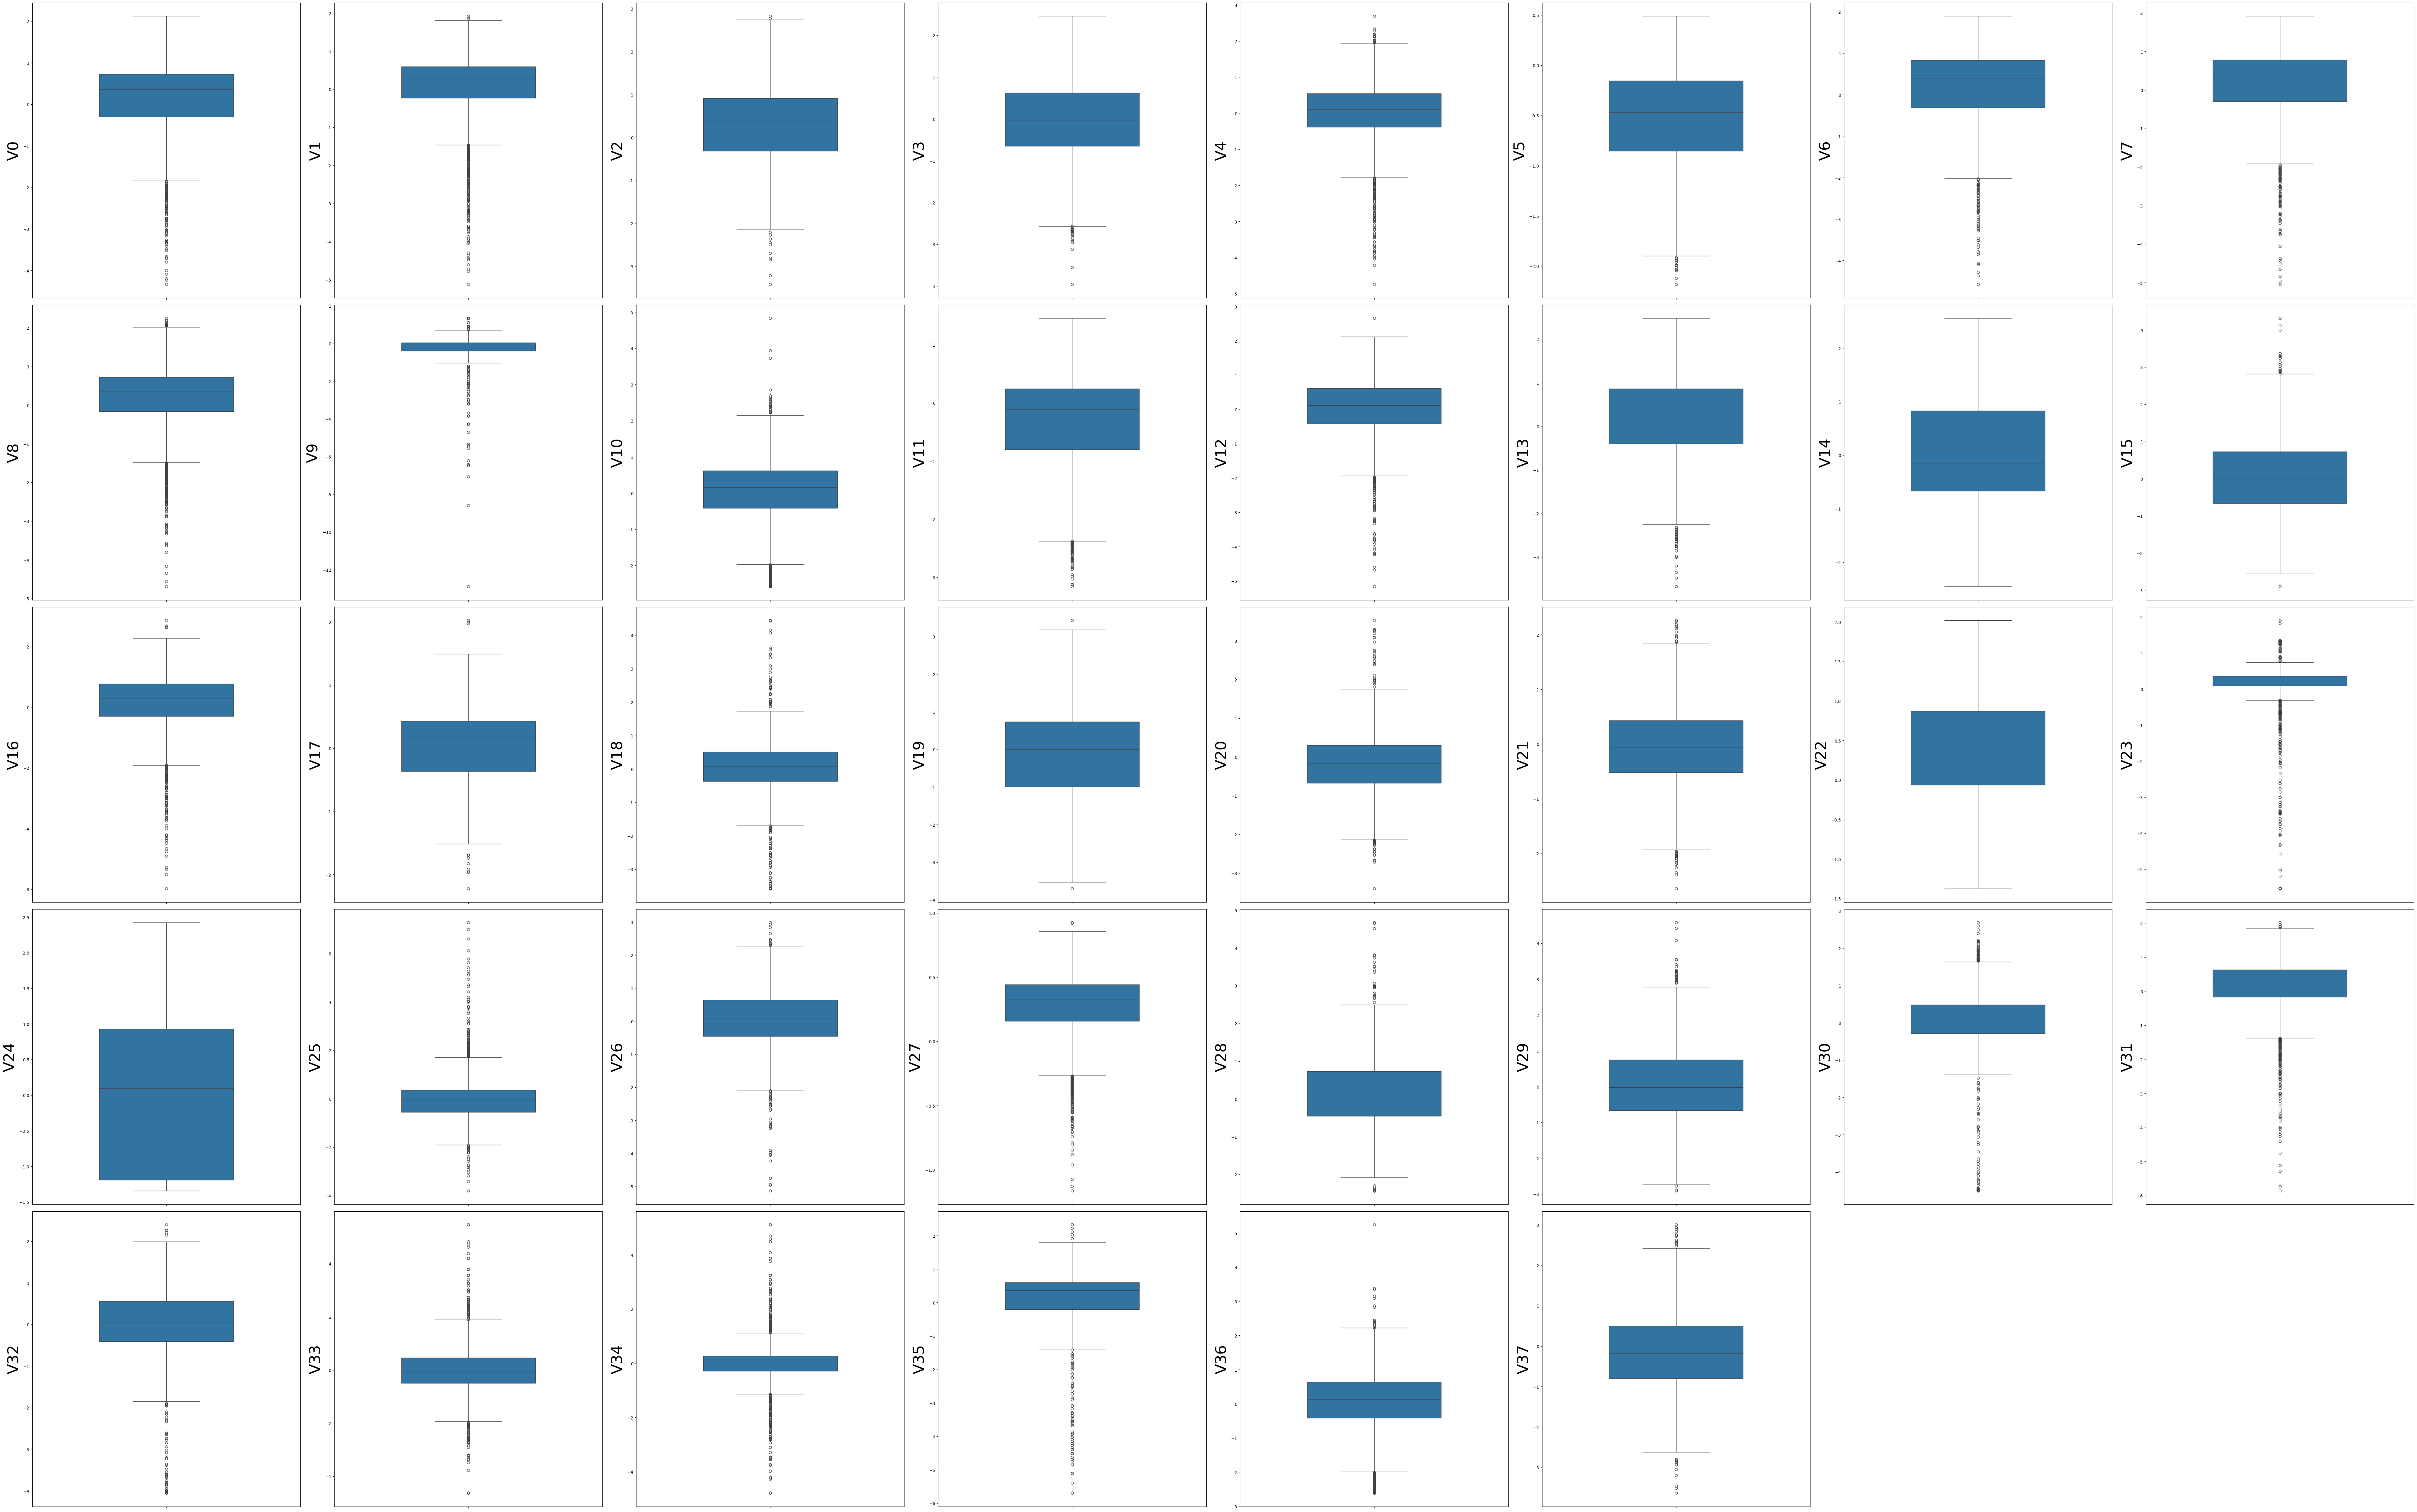

In [86]:
# 绘制箱线图 ----发现有许多异常值！
plt.figure(figsize = (80,70)) # 设置大画布的宽和高
# sns.boxplot(y = train_data['V0'], orient = 'v', width = 0.5) # 参数：（数据， 箱线方向垂直， 箱子宽度）

for i in range(38):
    plt.subplot(7,8, i+1) # 切换到第 i+1 个子图位置
    sns.boxplot(y = train_data[column[i]], orient = 'v', width = 0.5)
    plt.ylabel(column[i], fontsize = 36)
    
plt.tight_layout()  # 自动调整子图间距
plt.show()

In [87]:
# 获取异常数据



In [88]:
# # Q-Q图查看变量的分布是否与正态分布一致
# plt.figure(figsize = (10,5))

# ax = plt.subplot(1,2,1)
# sns.distplot(train_data['V0'], fit = stats.norm) # 直方图， 用正态分布拟合
# ax = plt.subplot(1,2,2)
# stats.probplot(train_data['V0'], plot = plt) # Q-Q图，绘图位置指定当前画布

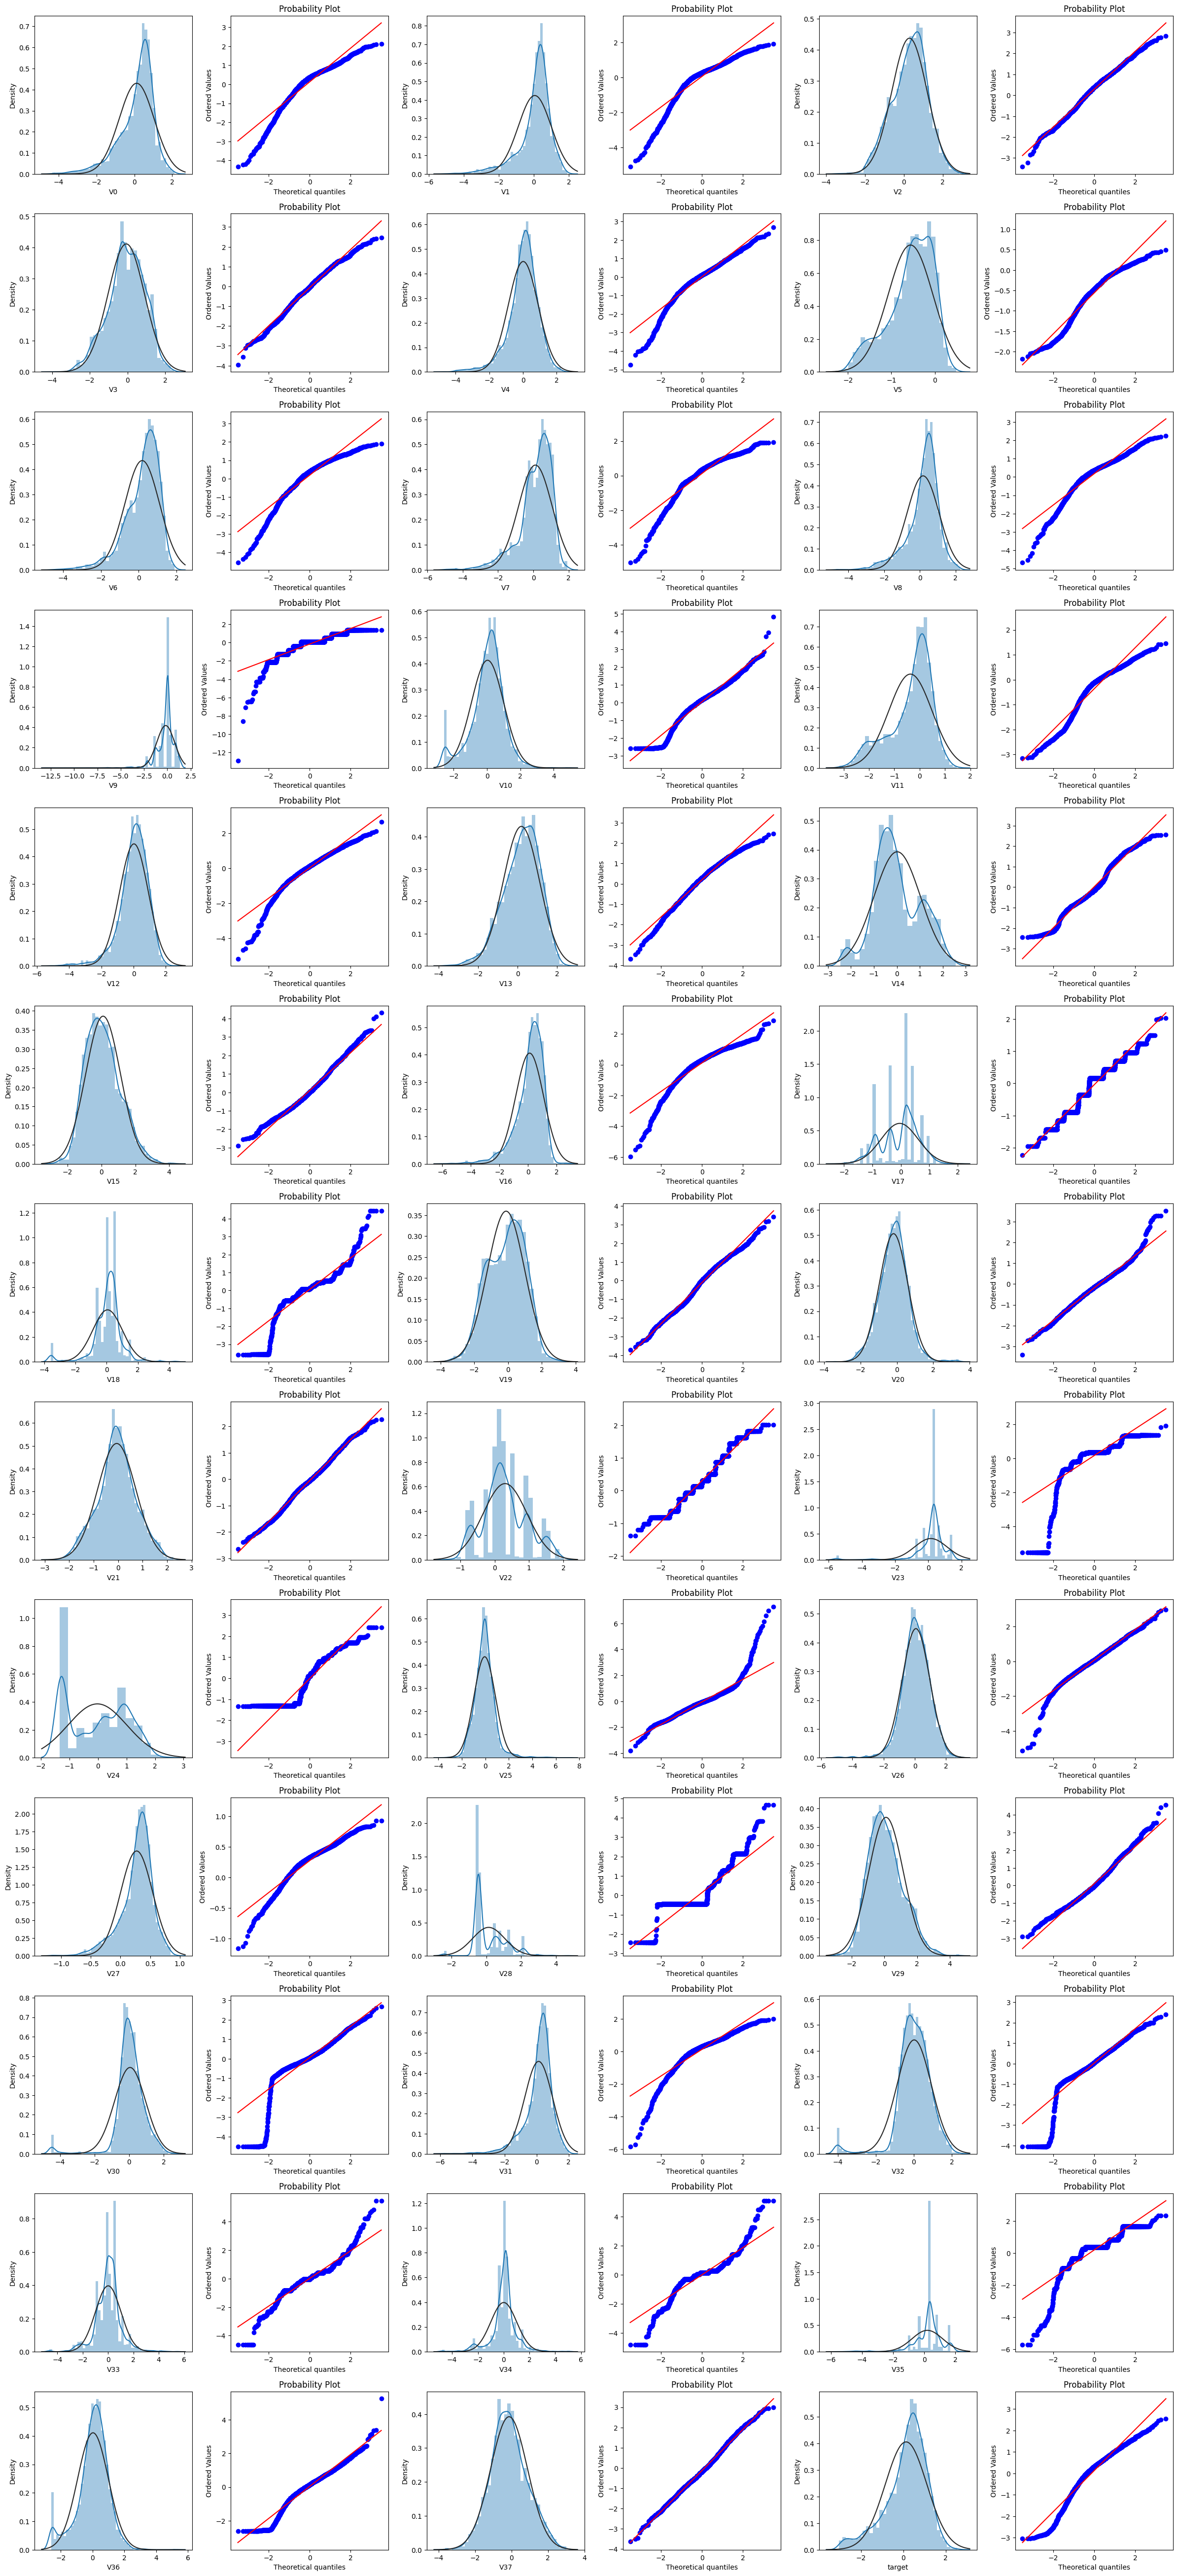

In [89]:
train_cols = 6
train_rows = (len(train_data.columns)*2)//train_cols + train_cols-1 # 7
plt.figure(figsize = (4*train_cols, 4*train_rows))

i = 0
for col in train_data.columns:
    i += 1
    ax = plt.subplot(train_rows, train_cols, i) # 指定为7行 6列网格中的第 i个位置
    sns.distplot(train_data[col], fit = stats.norm)

    i += 1
    ax = plt.subplot(train_rows, train_cols, i)
    stats.probplot(train_data[col], plot = plt)
plt.tight_layout()
plt.show()   

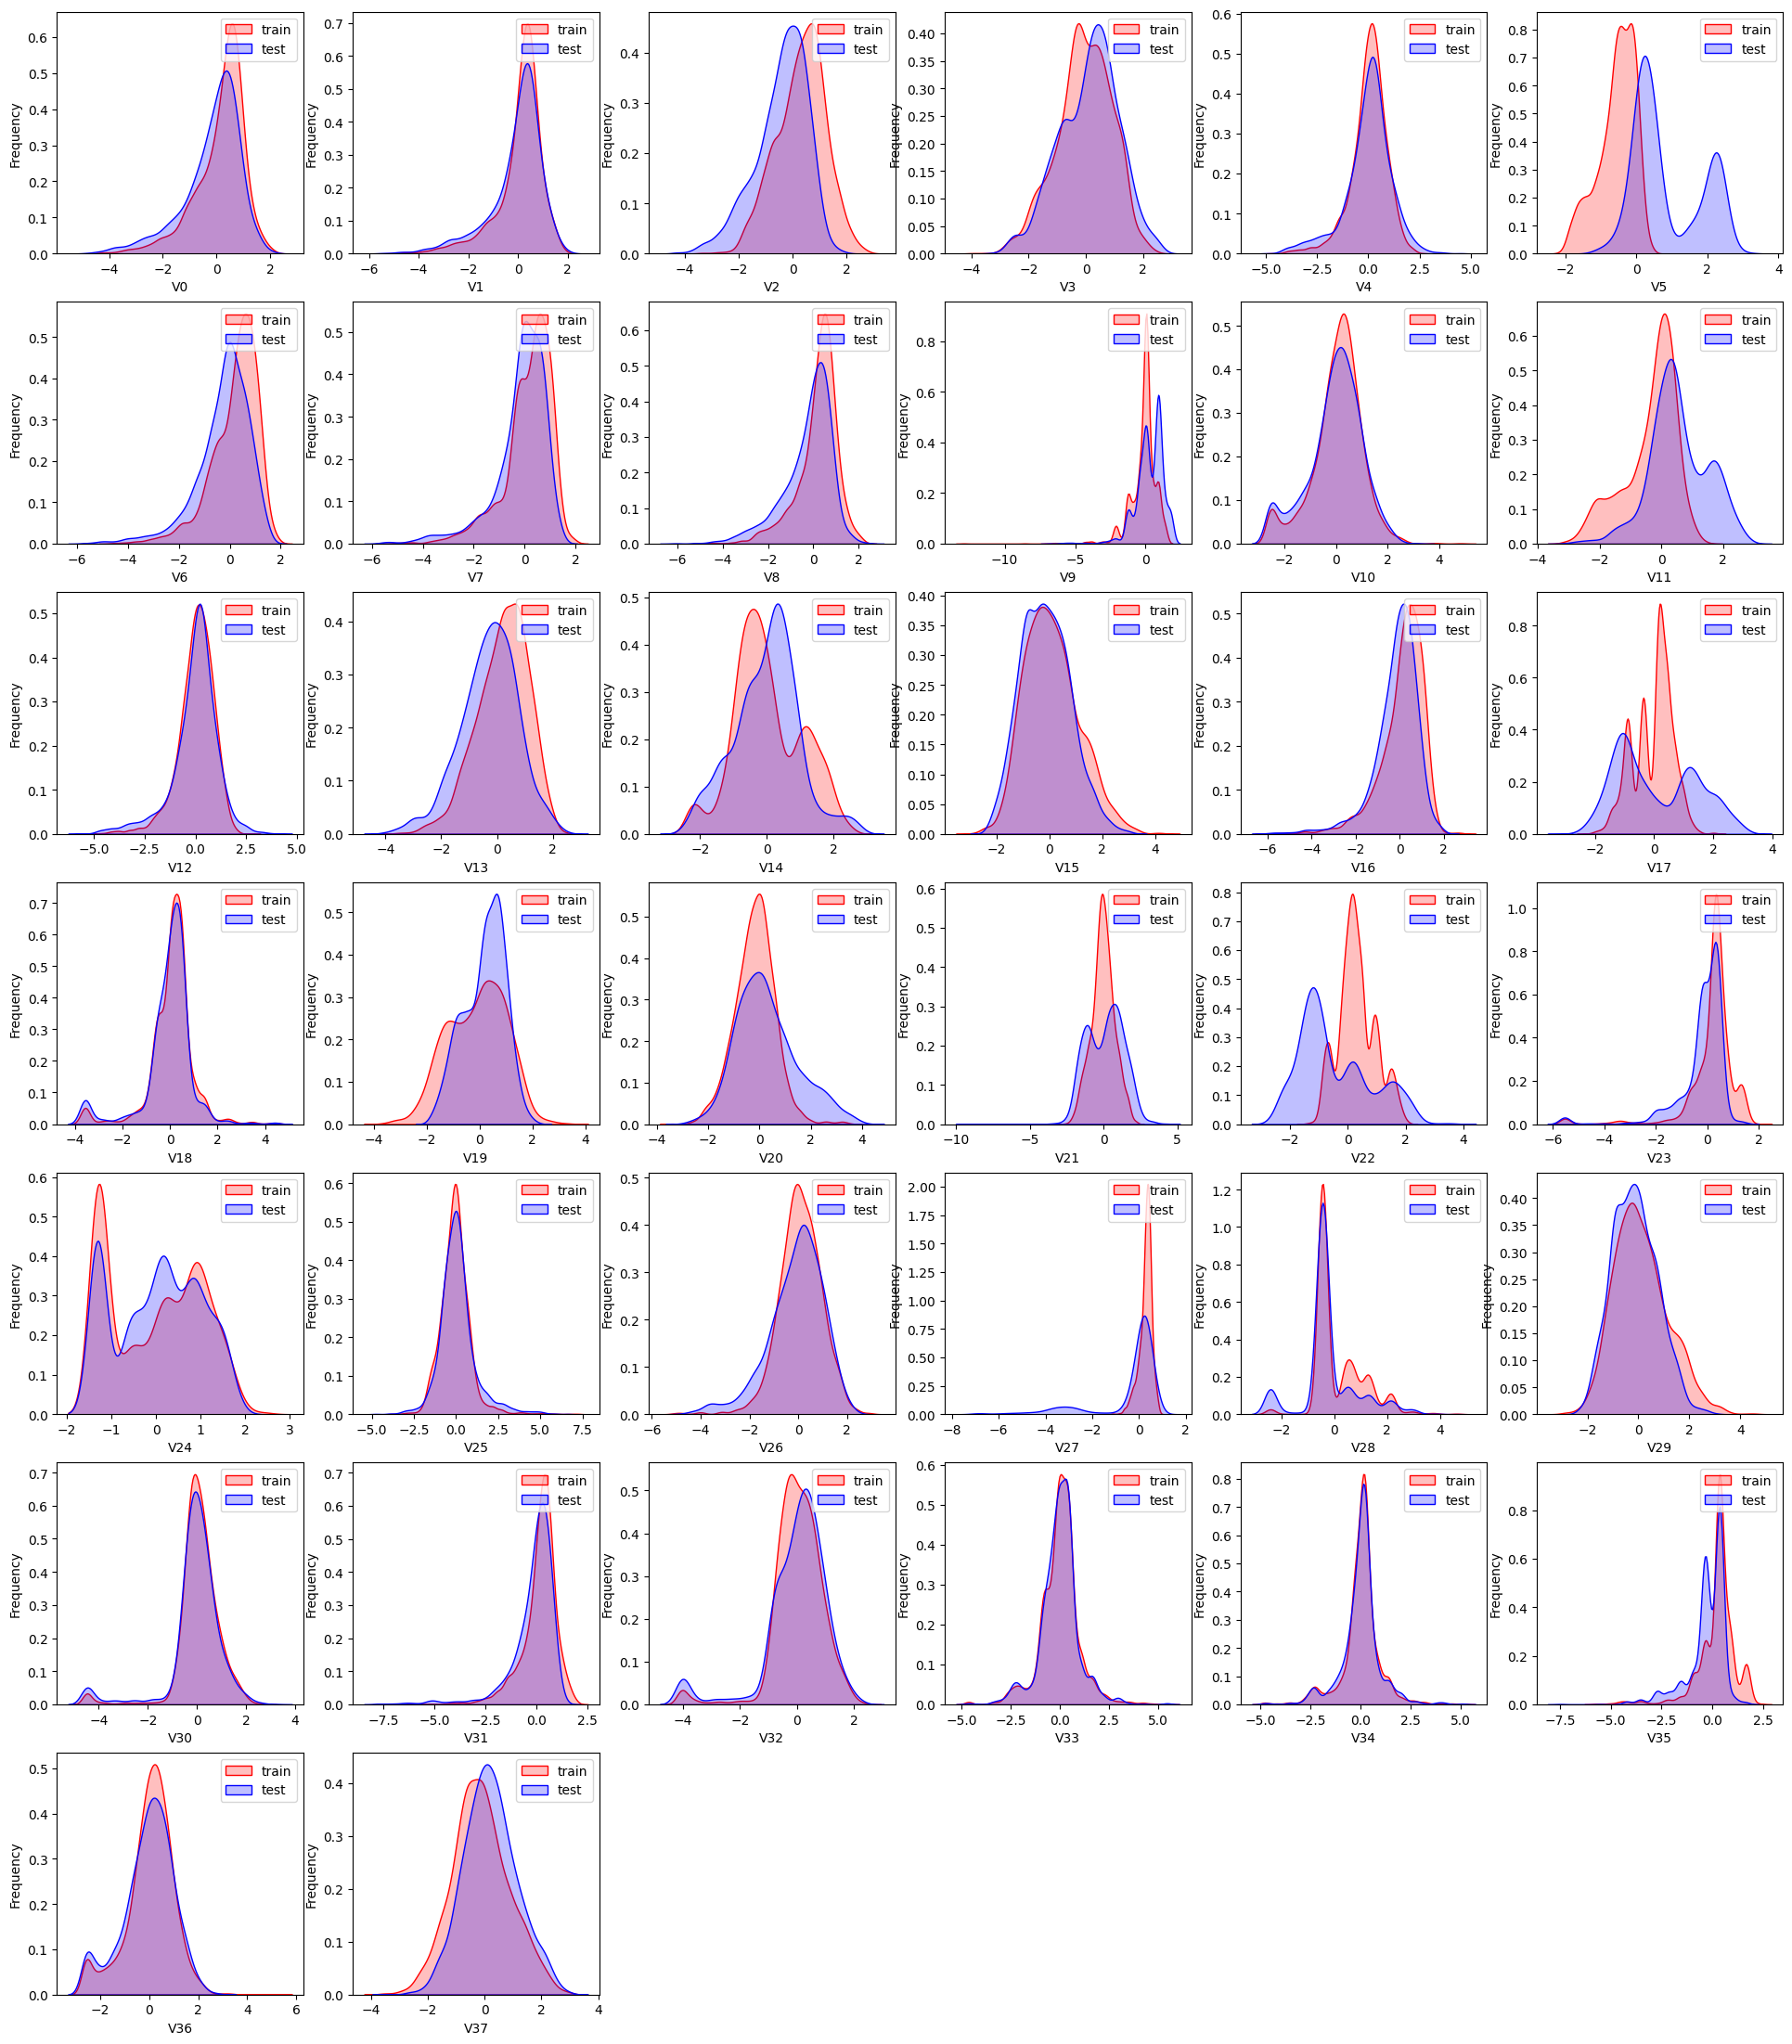

In [90]:
# KDE分布图---直方图的加窗（高斯核）平滑, 查看训练集和测试集的各个变量分布的差异情况
c = 6
r = len(column) //c + c-1
plt.figure(figsize = (c*4,r*4))
i = 1
for col in column:
    ax = plt.subplot(r,c, i)
    sns.kdeplot(train_data[col], color = 'red', shade = True)
    sns.kdeplot(test_data[col], color = 'blue', shade = True)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax = ax.legend(["train", "test"])
    i += 1
plt.show()


In [91]:
# 可以看出，训练集和测试集的 V5, V9, V11, V17, V22, V28变量分布不一致，会导致模型泛化能力变差，需要删除此类特征。
drop_columns = ['V5', 'V9', 'V11', 'V17', 'V22', 'V28']
data_train1 = train_data.drop(['V5', 'V9', 'V11', 'V17', 'V22', 'V28'], axis = 1)
data_train1.columns

Index(['V0', 'V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V8', 'V10', 'V12', 'V13',
       'V14', 'V15', 'V16', 'V18', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25',
       'V26', 'V27', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36',
       'V37', 'target'],
      dtype='object')

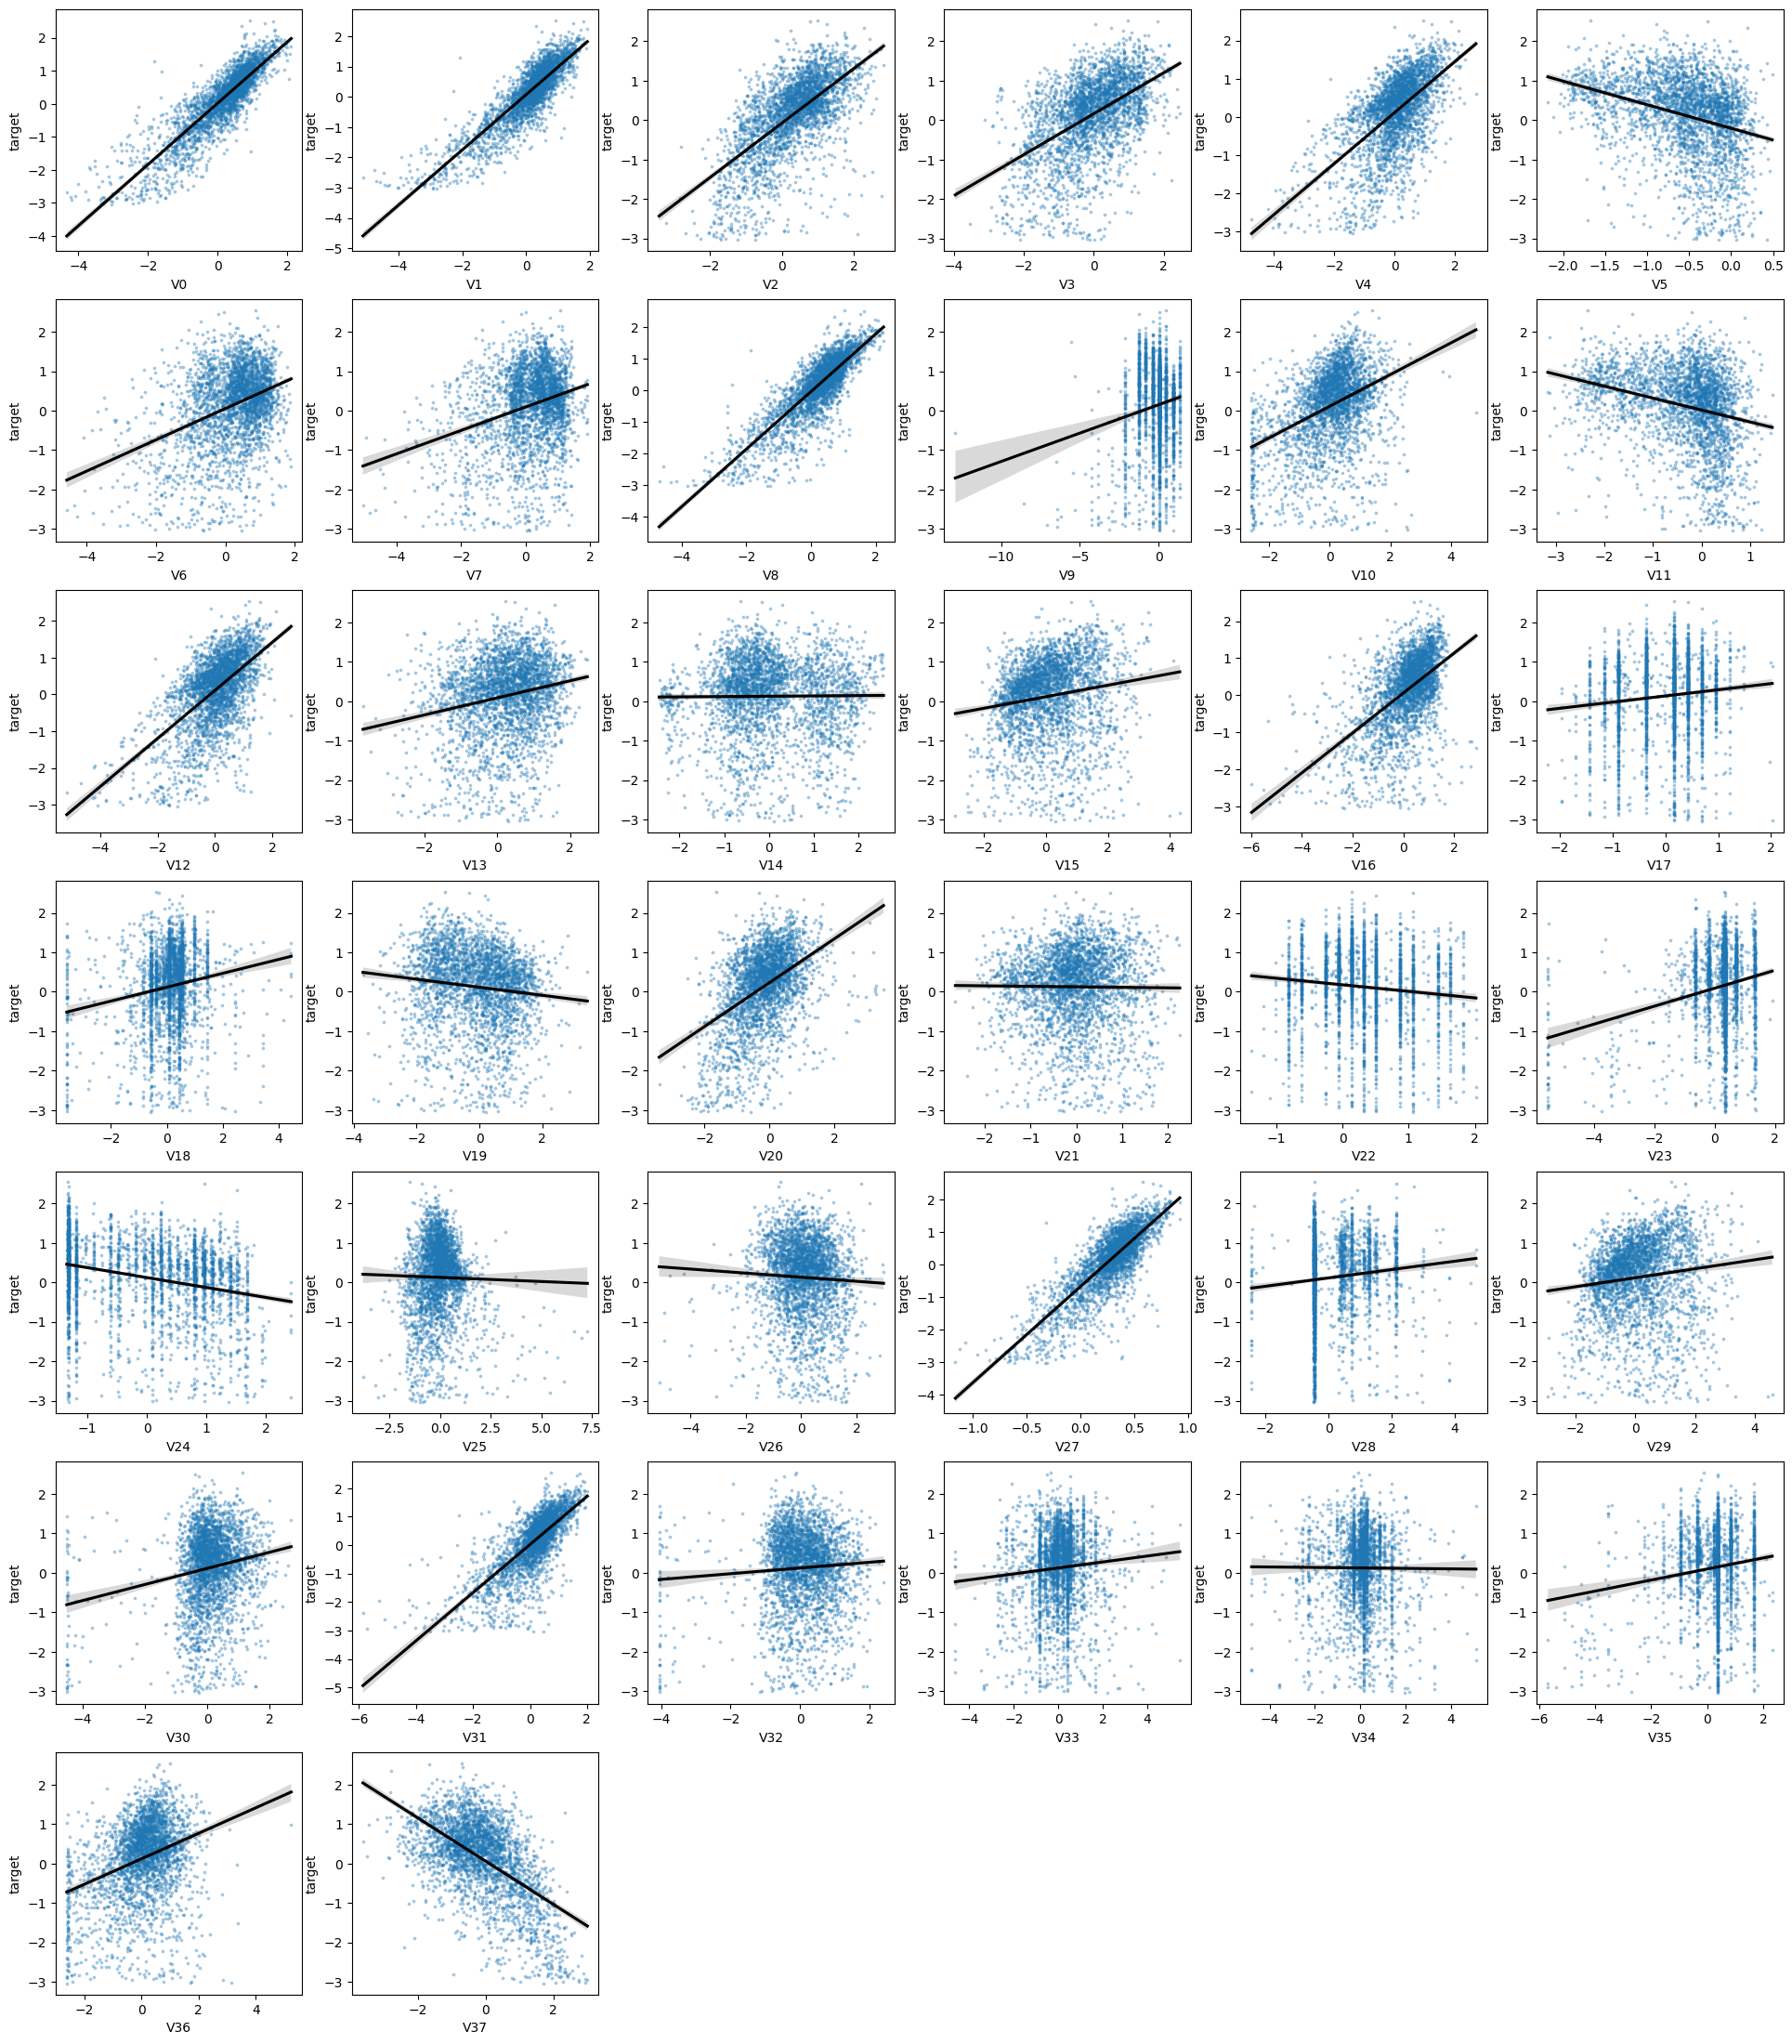

In [92]:
# 接下来查看特征与目标变量的关系

# 线性回归关系图
lc = 6
lr = len(column)//lc +lc-1
plt.figure(figsize = (lc*4, lr*4))
i = 1
for col in column:
    ax1 = plt.subplot(lr, lc, i)
    sns.regplot(
        x = col, y = 'target', data = train_data, ax = ax1,
        scatter_kws = {'marker':'.', 's':3, 'alpha':0.3},
        line_kws = {'color':'k'})
    ax1.set_xlabel(col)
    ax1.set_ylabel('target')
    i += 1
plt.show()   

In [93]:
# 查看所有变量间的相关关系
# 计算相关系数
train_corr = data_train1.corr(method = 'spearman')
train_corr

,V0,V1,V2,V3,V4,V6,V7,V8,V10,V12,...,V29,V30,V31,V32,V33,V34,V35,V36,V37,target
V0,1.000000,0.894256,0.517319,0.399921,0.696039,0.132296,0.076254,0.831926,0.278814,0.639393,...,0.333527,0.100600,0.738433,-0.050431,0.056298,-0.027432,0.039567,0.214309,-0.473005,0.866709
V1,0.894256,1.000000,0.490908,0.362483,0.650196,0.147891,0.083318,0.848793,0.255167,0.594844,...,0.239829,0.110668,0.806790,-0.014485,0.023336,-0.047713,0.034086,0.192307,-0.398149,0.832457
V2,0.517319,0.490908,1.000000,0.416179,0.061375,0.547371,0.379350,0.676597,0.292613,0.054992,...,-0.255811,0.177325,0.589526,-0.007595,0.050666,-0.045764,-0.051460,0.259177,-0.732023,0.630160
V3,0.399921,0.362483,0.416179,1.000000,0.294158,0.180536,0.132228,0.400345,0.295140,0.286590,...,0.128647,0.054423,0.420126,-0.131464,-0.032086,-0.052927,-0.015650,0.299315,-0.218281,0.501114
V4,0.696039,0.650196,0.061375,0.294158,1.000000,-0.205288,-0.150945,0.454619,0.122648,0.897896,...,0.691812,-0.054895,0.520877,-0.101759,0.058875,0.031054,0.102553,0.098678,0.041314,0.574775
V6,0.132296,0.147891,0.547371,0.180536,-0.205288,1.000000,0.904606,0.355517,0.336306,-0.195643,...,-0.486550,0.202681,0.339999,0.124914,0.037988,-0.062447,-0.131293,0.346199,-0.401693,0.264778
V7,0.076254,0.083318,0.379350,0.132228,-0.150945,0.904606,1.000000,0.278607,0.242932,-0.157466,...,-0.360334,0.196793,0.277269,0.107367,0.001650,-0.104076,-0.042363,0.268039,-0.284660,0.164981
V8,0.831926,0.848793,0.676597,0.400345,0.454619,0.355517,0.278607,1.000000,0.351478,0.367446,...,0.050198,0.165773,0.841188,-0.011658,0.018316,-0.075186,0.038945,0.263564,-0.507218,0.799280
V10,0.278814,0.255167,0.292613,0.295140,0.122648,0.336306,0.242932,0.351478,1.000000,0.108929,...,-0.059274,0.027177,0.445196,-0.075175,0.021731,-0.019655,-0.060051,0.892266,-0.025478,0.371067
V12,0.639393,0.594844,0.054992,0.286590,0.897896,-0.195643,-0.157466,0.367446,0.108929,1.000000,...,0.731735,-0.055326,0.471155,-0.074621,0.055579,0.037539,0.112444,0.084581,0.028968,0.542429


<Axes: >

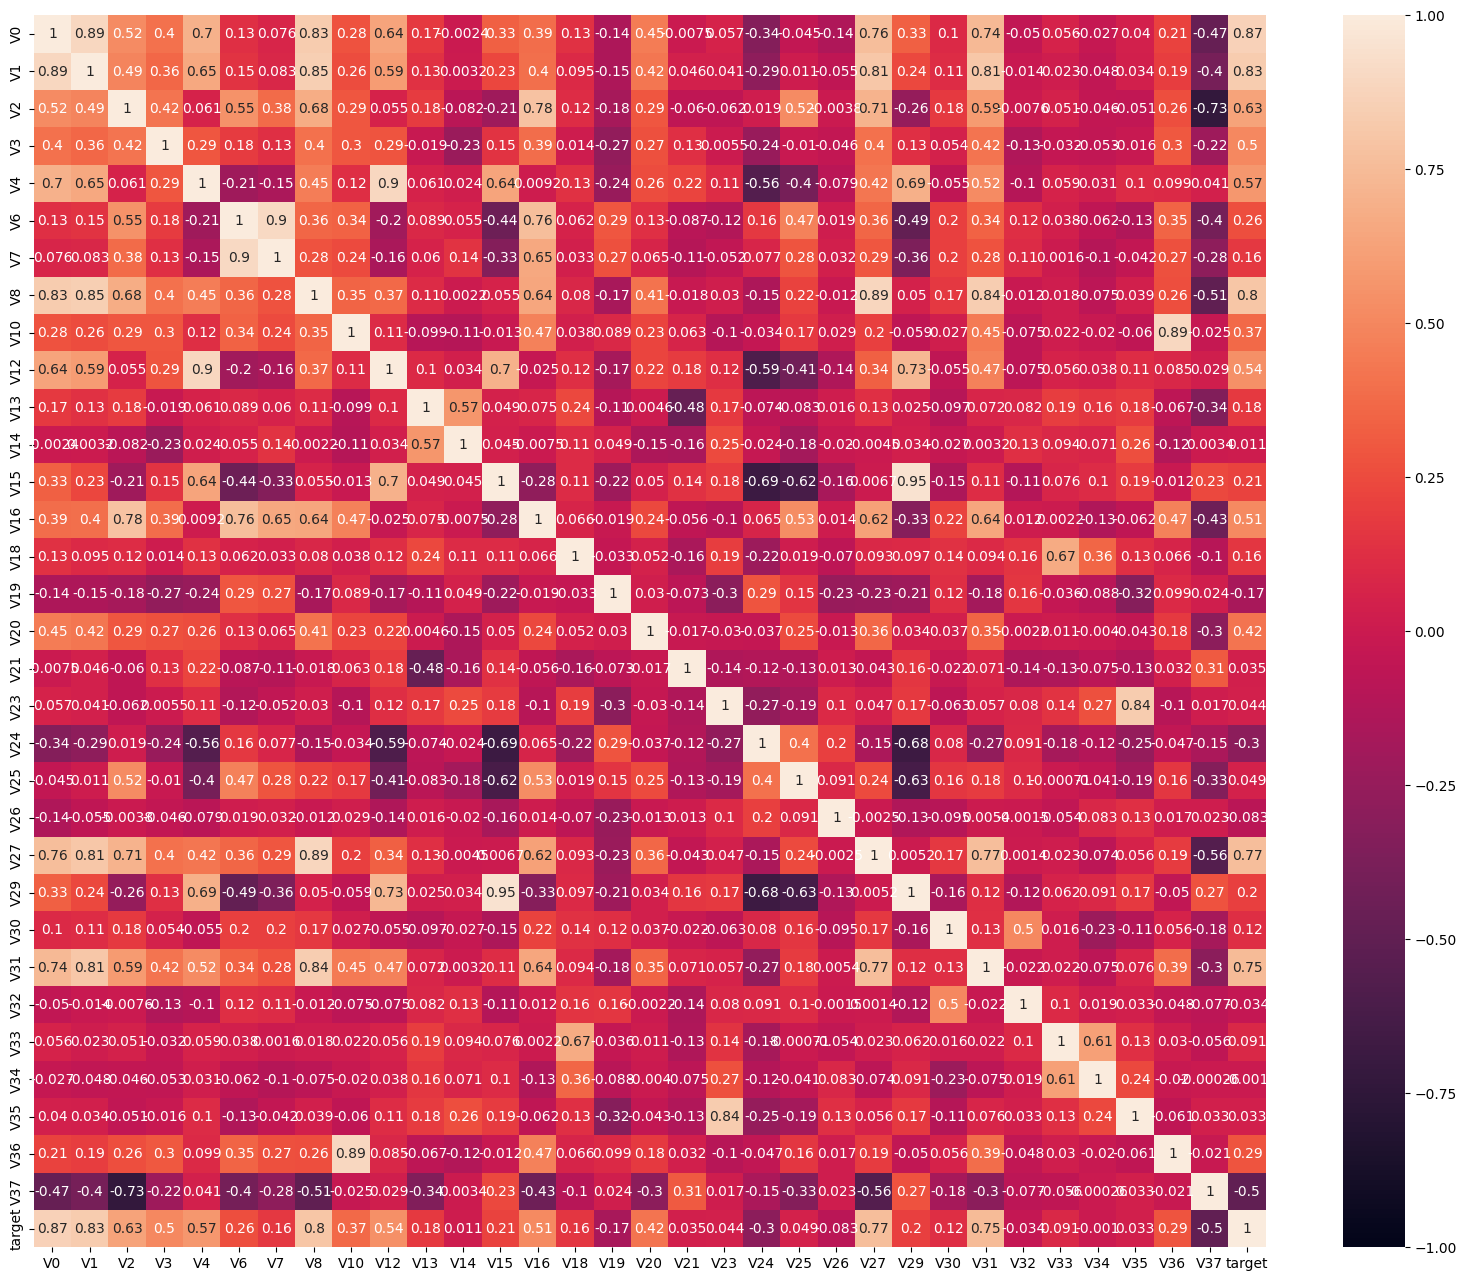

In [94]:
# 画出热力图
ax = plt.figure(figsize = (20,16))
sns.heatmap(train_corr, vmin = -1, vmax = 1, square = True, annot = True)

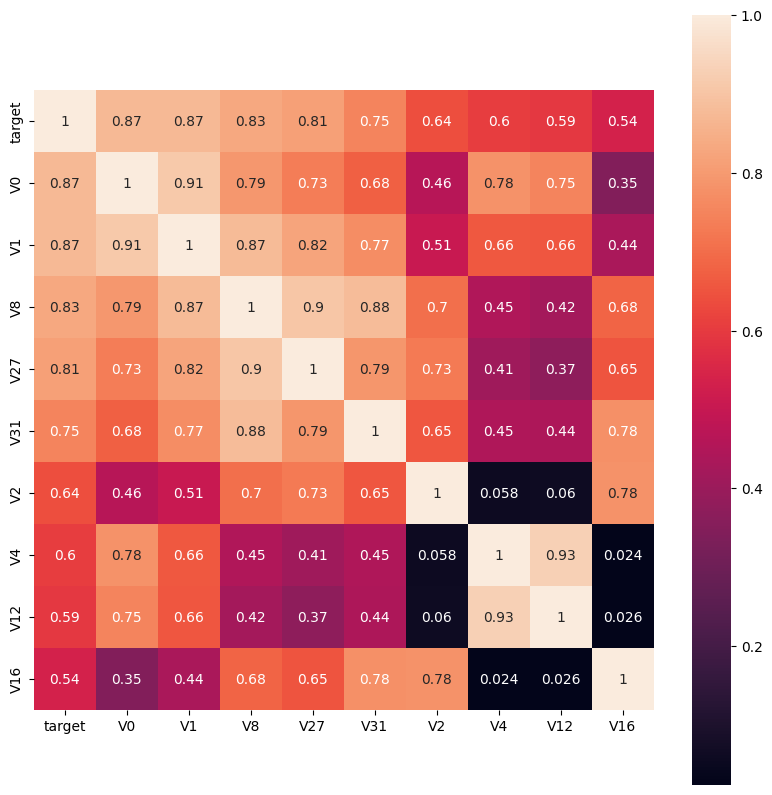

In [95]:
# 根据相关系数筛选特征
k = 10
cols = train_corr.nlargest(k, 'target')['target'].index

cm = np.corrcoef(train_data[cols].values.T) # 输出：NumPy数组，输出需要转置，因为默认计算行间的相关性
hm = plt.figure(figsize = (10,10))
hm = sns.heatmap(train_data[cols].corr(), annot = True, square = True) # 输出：Pandas DataFrame
plt.show()

In [96]:
threshold = 0.5
corr_matrix = train_corr.abs()
drop_col = corr_matrix[corr_matrix['target']<0.5].index
data_train2 = data_train1.drop(drop_col, axis = 1)

In [97]:
# Box-Cox 变换

In [98]:
train_x = data_train1.drop(['target'], axis = 1)
test_data.drop(drop_columns, axis = 1, inplace = True)
data_all = pd.concat([train_x,test_data], axis = 0)
data_all.head()


,V0,V1,V2,V3,V4,V6,V7,V8,V10,V12,...,V27,V29,V30,V31,V32,V33,V34,V35,V36,V37
0,0.566,0.016,-0.143,0.407,0.452,-1.812,-2.360,-0.436,-0.940,-0.073,...,0.168,0.136,0.109,-0.615,0.327,-4.627,-4.789,-5.101,-2.608,-3.508
1,0.968,0.437,0.066,0.566,0.194,-1.566,-2.360,0.332,0.188,-0.134,...,0.338,-0.128,0.124,0.032,0.600,-0.843,0.160,0.364,-0.335,-0.730
2,1.013,0.568,0.235,0.370,0.112,-1.367,-2.360,0.396,0.874,-0.072,...,0.326,-0.009,0.361,0.277,-0.116,-0.843,0.160,0.364,0.765,-0.589
3,0.733,0.368,0.283,0.165,0.599,-1.200,-2.086,0.403,0.011,-0.014,...,0.277,0.015,0.417,0.279,0.603,-0.843,-0.065,0.364,0.333,-0.112
4,0.684,0.638,0.260,0.209,0.337,-1.073,-2.086,0.314,-0.251,0.199,...,0.332,0.183,1.078,0.328,0.418,-0.843,-0.215,0.364,-0.280,-0.028


In [99]:
#采用 Min-Max 归一化， 由于box-cox变换要求正值
col_index = data_all.columns
data_all= data_all.apply(lambda x: (x - x.min()) / (x.max() - x.min()))
data_all.describe()

,V0,V1,V2,V3,V4,V6,V7,V8,V10,V12,...,V27,V29,V30,V31,V32,V33,V34,V35,V36,V37
count,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,...,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000
mean,0.694172,0.721357,0.602300,0.603139,0.523743,0.748823,0.745740,0.715607,0.348518,0.578507,...,0.881401,0.388683,0.589459,0.792709,0.628824,0.458493,0.483790,0.762873,0.332385,0.545795
std,0.144198,0.131443,0.140628,0.152462,0.106430,0.132560,0.132577,0.118105,0.134882,0.105088,...,0.128221,0.133475,0.130786,0.102976,0.155003,0.099095,0.101020,0.102037,0.127456,0.150356
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.626676,0.679416,0.514414,0.503888,0.478182,0.683324,0.696938,0.664934,0.284327,0.532892,...,0.888575,0.292445,0.550092,0.761816,0.562461,0.409037,0.454490,0.727273,0.270584,0.445647
50%,0.729488,0.752497,0.617072,0.614270,0.535866,0.774125,0.771974,0.742884,0.366469,0.591635,...,0.916015,0.375734,0.594428,0.815055,0.643056,0.454518,0.499949,0.800020,0.347056,0.539317
75%,0.790195,0.799553,0.700464,0.710474,0.585036,0.842259,0.836405,0.790835,0.432965,0.641971,...,0.932555,0.471837,0.650798,0.852229,0.719777,0.500000,0.511365,0.800020,0.414861,0.643061
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [100]:
n_train = train_data.shape[0]
data_train3 = data_all.iloc[:n_train,]
data_train3.columns

Index(['V0', 'V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V8', 'V10', 'V12', 'V13',
       'V14', 'V15', 'V16', 'V18', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25',
       'V26', 'V27', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36',
       'V37'],
      dtype='object')

In [101]:
# 1. 批量Box-Cox变换
from sklearn.preprocessing import PowerTransformer
# 确保数据为正数
X_positive = data_train3.dropna() + 1e-8  

# 批量变换
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X_positive)

# 2. 创建新数据集
train_data_batch = data_train3.copy()
for i, feature in enumerate(data_train3.columns):
    train_data_batch[f'{feature}_bc'] = X_transformed[:, i]

# 3. 批量分析变换效果
bc_features = [f'{feature}_bc' for feature in data_train3.columns]

# 计算偏度改善
skew_improvement = {}
for orig_feature, bc_feature in zip(data_train3.columns, bc_features):
    orig_skew = stats.skew(data_train3[orig_feature])
    bc_skew = stats.skew(train_data_batch[bc_feature])
    skew_improvement[orig_feature] = bc_skew - orig_skew

print("偏度改善总结:")
for feature, improvement in sorted(skew_improvement.items(), key=lambda x: x[1])[:10]:
    print(f"{feature}: {improvement:+.3f}")

偏度改善总结:
V25: -1.479
V24: -0.495
V29: -0.465
V15: -0.443
V14: -0.206
V37: -0.155
V20: -0.078
V33: +0.037
V21: +0.049
V19: +0.072


In [102]:
# train_data、test_data---原始数据
# data_train1---去掉与测试集分布不一致的 V5, V9, V11, V17, V22, V28变量后的训练集
# train_x = data_train1.drop(['target'], axis = 1)
# data_train2---data_train1中与target相关系数大于0.5的训练集变量
# data_all = pd.concat([train_x,test_data], axis = 0)且最大最小归一化后的特征变量
# data_train3---data_all.iloc[:n_train,]
# train_data_batch---归一化后的、去掉 V5, V9, V11, V17, V22, V28、target变量后的、经过box-cox变换后的训练特征。

### 三、特征工程

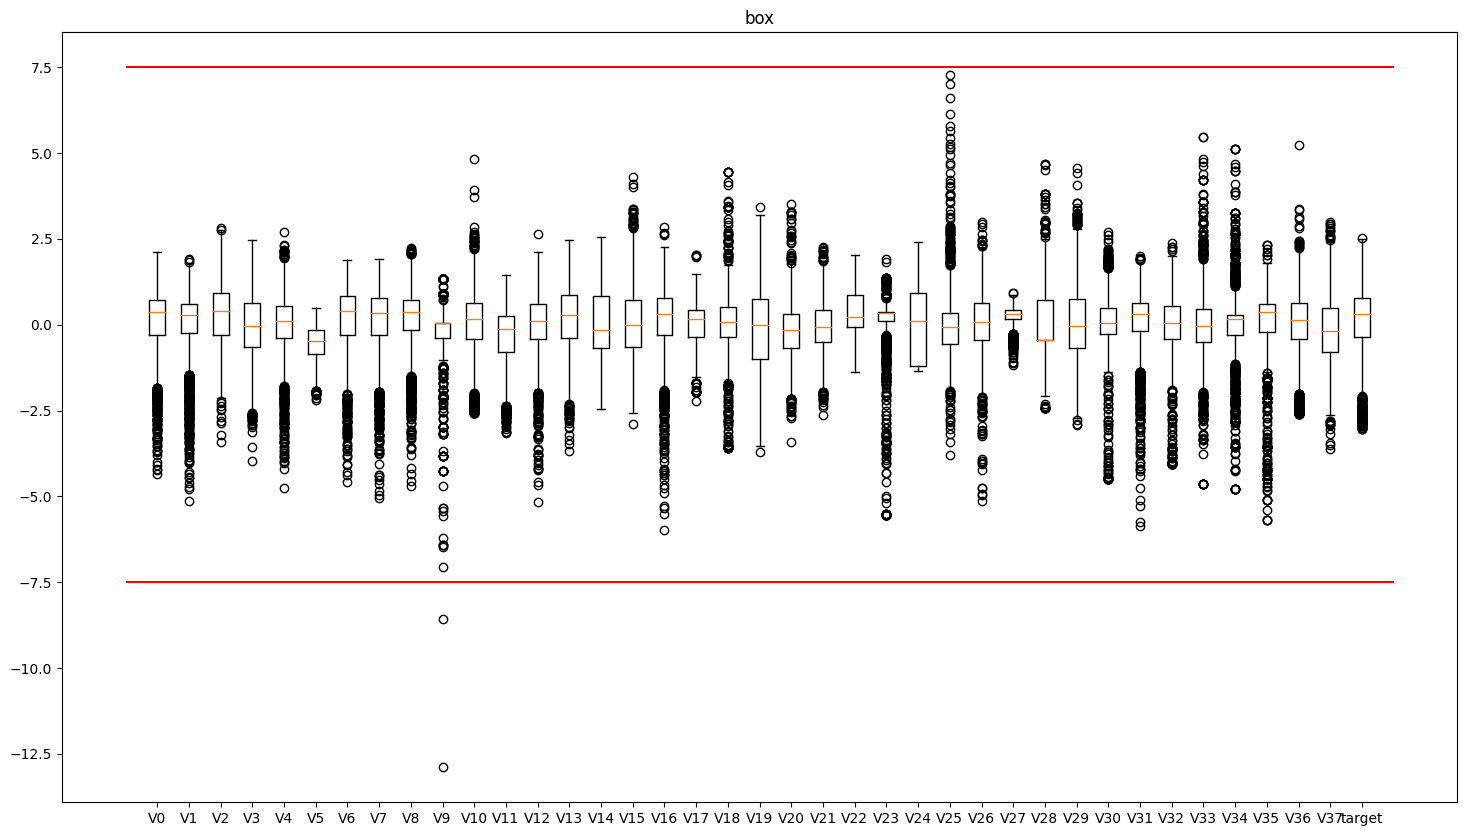

In [103]:
plt.figure(figsize = (18,10))
plt.boxplot(train_data.values,labels = train_data.columns)
plt.title('box')
plt.hlines([-7.5,7.5], 0, 40, colors = 'r')
plt.show()

In [106]:
# 删除异常值
train_data = train_data[train_data['V9'] >-7.5].reset_index(drop = True)
test_data = test_data[test_data['V9'] > -7.5].reset_index(drop = True)
train_data['V9'].describe()

count    2886.00000
mean       -0.16213
std         0.91089
min        -7.07100
25%        -0.39000
50%         0.04200
75%         0.04200
max         1.33500
Name: V9, dtype: float64

In [107]:
feature_all1 = pd.concat([train_data.iloc[:, :-1], test_data], axis = 0)
feature_cols = feature_all1.columns
feature_train = train_data.iloc[:, :-1]
from sklearn.preprocessing import MinMaxScaler
feature_all_scaler = pd.DataFrame(MinMaxScaler().fit_transform(feature_all1), columns = feature_cols)
feature_train_scaler = pd.DataFrame(MinMaxScaler().fit_transform(feature_train), columns = feature_cols)
feature_test_scaler = pd.DataFrame(MinMaxScaler().fit_transform(test_data), columns = feature_cols)

In [108]:
feature_train_scaler.describe()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37
count,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,...,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000
mean,0.690633,0.735633,0.593844,0.606212,0.639787,0.607649,0.735477,0.741354,0.702053,0.821897,...,0.361940,0.401631,0.634466,0.760495,0.632231,0.459302,0.484489,0.734944,0.336235,0.527608
std,0.143740,0.133703,0.145844,0.151311,0.119504,0.193887,0.141896,0.137154,0.129098,0.108362,...,0.130690,0.141594,0.124279,0.110938,0.139037,0.099799,0.101365,0.122840,0.123663,0.153192
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.626239,0.695703,0.497759,0.515087,0.586328,0.497566,0.659249,0.682314,0.653489,0.794789,...,0.278638,0.300053,0.587132,0.722593,0.565757,0.409037,0.454490,0.685279,0.279792,0.427036
50%,0.727153,0.766335,0.609155,0.609855,0.652873,0.642456,0.767192,0.774189,0.728557,0.846181,...,0.279764,0.385611,0.633894,0.782330,0.634770,0.454518,0.499949,0.755580,0.349860,0.519457
75%,0.783922,0.812642,0.694422,0.714096,0.712152,0.759266,0.835690,0.837030,0.781029,0.846181,...,0.445363,0.488121,0.694136,0.824949,0.714950,0.504261,0.511365,0.785260,0.414447,0.621870
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [109]:
m = train_data.shape[0]

In [110]:
feature_train_scaler1 = feature_all_scaler.iloc[:m]
feature_test_scaler1 = feature_all_scaler.iloc[m:]
feature_train_scaler.shape

(2886, 38)

In [111]:
feature_test_scaler.shape

(1925, 38)

In [112]:
drop_kde_columns = ['V5', 'V9', 'V11', 'V17', 'V22', 'V28']
# 去掉kde分布不一致的变量
feature_train_kde = feature_train_scaler.drop(drop_kde_columns, axis = 1)
feature_test_kde = feature_test_scaler.drop(drop_kde_columns, axis = 1)

In [113]:
feature_train_kde.shape
feature_test_kde.shape

(1925, 32)

In [114]:
train_data['target'].shape

(2886,)

In [115]:
data_train_kde = pd.concat([feature_train_kde, train_data['target']],axis = 1)
data_train_kde.shape

(2886, 33)

In [116]:
corr1 = data_train_kde.corr(method = 'spearman')

In [117]:
obvious_f = corr1[corr1['target']>0.1]['target'].abs()
obvious_f.sort_values(ascending = False)

target    1.000000
V0        0.866523
V1        0.832175
V8        0.799548
V27       0.764757
V31       0.749838
V2        0.629754
V4        0.576065
V12       0.543660
V16       0.510412
V3        0.502582
V20       0.419515
V10       0.372017
V36       0.288616
V6        0.264083
V15       0.214283
V29       0.199393
V13       0.177776
V7        0.164521
V18       0.161400
V30       0.122005
Name: target, dtype: float64

In [118]:
index_corr = corr1[corr1['target']>0.2].index.tolist()

In [119]:
# # 计算方差膨胀因子
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# X = np.matrix(data_train_kde[index_corr])
# VIF = sorted([variance_inflation_factor(data_train_kde[index_corr].values, i) for i in range(data_train_kde[index_corr].shape[1])])
# VIF

In [120]:
# 主成分降维
from sklearn.decomposition import PCA

pca = PCA(n_components = 16)
new_train_pca = pd.DataFrame(pca.fit_transform(feature_train_scaler))
new_test_pca = pd.DataFrame(pca.fit_transform(feature_test_scaler))
new_train_pca['target'] = data_train_kde['target']
new_train_pca.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,target
count,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2.886000e+03,2886.000000
mean,2.363552e-16,3.939253e-17,-1.969626e-17,-1.920386e-16,5.908879e-17,2.215830e-17,9.848132e-18,1.600321e-17,-1.723423e-17,-5.785778e-17,-9.848132e-18,9.848132e-18,-5.170269e-17,-7.386099e-17,-3.077541e-17,1.231017e-16,0.127451
std,3.998976e-01,3.500240e-01,2.938631e-01,2.728023e-01,2.077128e-01,1.951842e-01,1.877104e-01,1.607670e-01,1.512707e-01,1.443772e-01,1.368790e-01,1.286192e-01,1.193301e-01,1.149758e-01,1.133507e-01,1.019259e-01,0.983144
min,-1.071795e+00,-1.382802e+00,-1.010250e+00,-1.448007e+00,-7.703987e-01,-1.358962e+00,-6.191589e-01,-5.870755e-01,-6.282818e-01,-5.839586e-01,-6.341045e-01,-5.906753e-01,-4.175153e-01,-4.310613e-01,-4.673189e-01,-3.601627e-01,-3.044000
25%,-2.804085e-01,-2.317720e-01,-2.069571e-01,-1.657590e-01,-1.315620e-01,-9.993122e-02,-1.272081e-01,-1.016452e-01,-9.662098e-02,-9.059634e-02,-8.202809e-02,-7.721868e-02,-7.139961e-02,-7.474073e-02,-7.116829e-02,-6.603914e-02,-0.347500
50%,-1.417104e-02,1.277241e-02,-2.112166e-02,2.337401e-02,-5.122797e-03,1.355336e-02,1.747870e-04,-4.656359e-03,2.572054e-03,1.479172e-03,7.286444e-03,-5.745946e-03,-4.140670e-03,1.054915e-03,1.758387e-03,-7.533392e-04,0.314000
75%,2.287306e-01,2.613727e-01,2.090797e-01,1.945196e-01,1.281660e-01,1.264097e-01,1.236360e-01,9.657222e-02,1.002626e-01,9.297088e-02,8.833765e-02,7.148033e-02,6.786199e-02,7.574868e-02,7.709743e-02,6.357449e-02,0.793750
max,1.597730e+00,9.429479e-01,9.948314e-01,7.103087e-01,1.034061e+00,5.340294e-01,5.993766e-01,7.370089e-01,6.449125e-01,4.902583e-01,6.405187e-01,6.780732e-01,5.156118e-01,4.978126e-01,4.170535e-01,4.570870e-01,2.538000


### 四、模型训练

In [121]:
# 1、线性回归
from sklearn.model_selection import train_test_split
new_train_pca = new_train_pca.fillna(0)
train = new_train_pca.iloc[:,:-1]
target = new_train_pca['target']

# 切分数据集：使用相同的random_state确保结果可重现
train_data2, test_data2, train_target2, test_target2 = train_test_split(train, target, test_size = 0.2, random_state = 0) 
train_data2.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], dtype='object')

In [122]:
# 调用模型
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

clf = LinearRegression()
clf.fit(train_data2, train_target2)
test_pred2 = clf.predict(test_data2)
score = mean_squared_error(test_target2,test_pred2)
print(f"LinearRegression score :{score}")

LinearRegression score :0.12815247032104632


In [123]:
# 2、K近邻回归
from sklearn.neighbors import KNeighborsRegressor

clf2 = KNeighborsRegressor(n_neighbors = 8)
clf2.fit(train_data2, train_target2)
test_pred_k = clf2.predict(test_data2)
score_k = mean_squared_error(test_target2, test_pred_k)
print(f"KNeighborsRegression score:{score_k}")

KNeighborsRegression score:0.1950816592506488


In [124]:
# 3、决策树回归
from sklearn.tree import DecisionTreeRegressor

clf3 = DecisionTreeRegressor()
clf3.fit(train_data2, train_target2)
test_pred_t = clf3.predict(test_data2)
score_t = mean_squared_error(test_target2, test_pred_t)
print(f"DesicionTreeRegressor score:{score_t}")

DesicionTreeRegressor score:0.3128567162629758


In [125]:
# 4、随机森林回归模型   # sklearn.ensemble集成学习库 
# Bagging（自举汇聚法）+ 决策树 + 特征随机性
from sklearn.ensemble import RandomForestRegressor
 
clf4 = RandomForestRegressor(n_estimators = 200)
clf4.fit(train_data2, train_target2)
test_pred_rf = clf4.predict(test_data2)
score_rf = mean_squared_error(test_target2, test_pred_rf)
print(f"RandomForestRegressor score:{score_rf}")

RandomForestRegressor score:0.15528492517698952


In [126]:
# 5、LightGBM模型回归
import lightgbm as lgb
clf5 = lgb.LGBMRegressor(
    learning_rate = 0.01,
    max_depth = -1,
    n_estimators = 5000,
    boosting_type = 'gbdt',
    random_state = 2019,
    objective = 'regression')

clf5.fit(X = train_data2, y = train_target2, eval_metric = 'MSE', callbacks = [lgb.log_evaluation(50)])
score_lgb = mean_squared_error(test_target2, clf5.predict(test_data2))
print(f"LightGBM score:{score_lgb}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 2308, number of used features: 16
[LightGBM] [Info] Start training from score 0.122935
LightGBM score:0.14563903891827373


In [127]:
# 模型过拟合和欠拟合
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(3)
train_data_poly = poly.fit_transform(train_data2)
test_data_poly = poly.transform(test_data2)
clf6 = SGDRegressor(max_iter = 1000, tol = 1e-3) # tolerance
clf6.fit(train_data_poly, train_target2)
score_train_poly = mean_squared_error(train_target2, clf6.predict(train_data_poly))
score_test_poly = mean_squared_error(test_target2, clf6.predict(test_data_poly))
print(f"PolynomialFeatures SGDRegressor  train score:{score_train_poly}")
print(f"PolynomialFeatures SGDRegressor test score:{score_test_poly}")

PolynomialFeatures SGDRegressor  train score:0.13604847376604454
PolynomialFeatures SGDRegressor test score:0.14268928344082446


In [128]:
# ElasticNet 正则化
poly = PolynomialFeatures(3)
train_data_poly = poly.fit_transform(train_data2)
test_data_poly = poly.transform(test_data2)
clf6 = SGDRegressor(max_iter = 1000, tol = 1e-3, penalty = 'elasticnet', l1_ratio = 0.9, alpha = 1e-5) # tolerance
clf6.fit(train_data_poly, train_target2)
score_train_poly = mean_squared_error(train_target2, clf6.predict(train_data_poly))
score_test_poly = mean_squared_error(test_target2, clf6.predict(test_data_poly))
print(f"PolynomialFeatures SGDRegressor train score:{score_train_poly}")
print(f"PolynomialFeatures SGDRegressor test score:{score_test_poly}")

PolynomialFeatures SGDRegressor train score:0.13495031913420633
PolynomialFeatures SGDRegressor test score:0.1413176519175542


In [129]:
# K 折交叉验证
from sklearn.model_selection import KFold
kf = KFold(n_splits = 5)
for k, (train_index, test_index) in enumerate(kf.split(train)):
    train_data_k, train_target_k, test_data_k, test_target_k = train.values[train_index], target[train_index], train.values[test_index], target.values[test_index]
    clf7 = SGDRegressor(max_iter = 1000, tol = 1e-3, penalty = 'elasticnet', l1_ratio = 0.9, alpha = 1e-5) # tolerance
    clf7.fit(train_data_k, train_target_k)
    score_train_k = mean_squared_error(train_target_k, clf7.predict(train_data_k))
    score_test_k = mean_squared_error(test_target_k, clf7.predict(test_data_k))
    print(f"{k}折 SGDRegressor train score:{score_train_k}")
    print(f"{k}折 SGDRegressor test score:{score_test_k}")

0折 SGDRegressor train score:0.1503656948009694
0折 SGDRegressor test score:0.10556854881842283
1折 SGDRegressor train score:0.13265649375945532
1折 SGDRegressor test score:0.18287888904380048
2折 SGDRegressor train score:0.1461389102011174
2折 SGDRegressor test score:0.13433032178950913
3折 SGDRegressor train score:0.1415381017125416
3折 SGDRegressor test score:0.16011266858899487
4折 SGDRegressor train score:0.13808525183671125
4折 SGDRegressor test score:0.16538690794996436


### 五、模型超参空间及调参

In [130]:
from sklearn.model_selection import GridSearchCV

randomforestregressor = RandomForestRegressor()
parameters = {'n_estimators':[50,100,200], 'max_depth':[1,2,3]}
# cv=5：使用5折交叉验证评估每个参数组合
# 对9种参数组合分别训练模型；每种组合使用5折交叉验证评估性能；总共训练 9 × 5 = 45 个模型
clf8 = GridSearchCV(randomforestregressor, parameters, cv = 5) 

clf8.fit(train_data2, train_target2)
# GridSearchCV默认 refit=True，会用最佳参数在整个train_data2上重新训练一个最终模型， 以下是最终结果 mse
score_train_cv = mean_squared_error(train_target2, clf8.predict(train_data2))
score_test_cv = mean_squared_error(test_target2, clf8.predict(test_data2))
print(f"RandomForestRegressior GridSearchCV train score:{score_train_cv}")
print(f"RandomForestRegressior GridSearchCV test score:{score_test_cv}")

sorted(clf8.cv_results_) # 最佳参数的交叉验证分数 (clf8.best_score_)

RandomForestRegressior GridSearchCV train score:0.23892666481443856
RandomForestRegressior GridSearchCV test score:0.24431208717258762


['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_max_depth',
 'param_n_estimators',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [131]:
print("最佳参数:", clf8.best_params_)
print("最佳交叉验证分数:", clf8.best_score_)
print("最佳估计器:", clf8.best_estimator_)

最佳参数: {'max_depth': 3, 'n_estimators': 100}
最佳交叉验证分数: 0.7287125740784218
最佳估计器: RandomForestRegressor(max_depth=3)


In [132]:
from sklearn.model_selection import RandomizedSearchCV
# 默认只随机搜索10种组合
randomforestregressor = RandomForestRegressor()
parameters_r = {'n_estimators':[50,100,200,300], 'max_depth':[1,2,3,4,5]}
clf9 = RandomizedSearchCV(randomforestregressor, parameters_r, cv = 5) 

clf9.fit(train_data2, train_target2)
# SearchCV默认 refit=True，会用最佳参数在整个train_data2上重新训练一个最终模型， 以下是最终结果 mse
score_test_rcv = mean_squared_error(test_target2, clf9.predict(test_data2))
print(f"RandomForestRegressior RandomizedSearchCV test score:{score_test_rcv}")

sorted(clf9.cv_results_) # 最佳参数的交叉验证分数 (clf8.best_score_)

RandomForestRegressior RandomizedSearchCV test score:0.19153325128820906


['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_max_depth',
 'param_n_estimators',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']